# ML-09+ — Evidence Audit: Is the Win Bigger Than the Noise?

**Câu hỏi.** Capstone báo cáo precision@50 = 0.88 so với 0.74 của rule baseline, PR-AUC 0.718 so với 0.668.
Đó là *ước lượng điểm* trên **30 client** — và một client chiếm gần 1/3 số trang. Với mẫu nhỏ như vậy,
một con số đẹp chưa phải là bằng chứng. Notebook này tấn công kết quả của chính mình theo sáu hướng:

| # | Đòn tấn công | Câu hỏi nó trả lời |
|---|---|---|
| 1 | Permutation test (huấn luyện lại toàn bộ pipeline trên nhãn bị xáo) | Có tín hiệu thật không, hay chỉ là may mắn? |
| 2 | Bootstrap theo **client** (không phải theo dòng), ghép cặp | Khoảng dao động thật của từng chỉ số và của khoảng cách model − rule |
| 3 | So sánh **bên trong từng client** | Model thắng nhờ xếp hạng trang, hay chỉ nhờ xếp hạng client? |
| 4 | Độ nhạy: 4 ngưỡng demand × 3 ngưỡng suy giảm, bỏ client lớn nhất | Kết luận có sống sót khi đổi định nghĩa không? |
| 5 | Gradient boosting làm đối thủ | Độ phức tạp có đáng không? |
| 6 | Calibration | Điểm rủi ro có đọc được như xác suất không? |

Mọi con số dưới đây được ghi vào `work/outputs/evidence_audit.json` (receipt được commit) và được
`tests/test_capstone.py` đối chiếu với README, báo cáo, model card và paper.

In [1]:
# --- Bootstrap: chạy được cả ở local lẫn trên Colab ---
import os, sys, json, urllib.request

BASE = "https://raw.githubusercontent.com/tu-h-nguyn/FlyRank-Machine-Learning-Internship/main"

def _scripts_dir() -> str:
    for p in ["../scripts", "work/scripts", "scripts", "../../work/scripts"]:
        if os.path.exists(os.path.join(p, "evidence_audit.py")):
            return p
    os.makedirs("work/scripts", exist_ok=True)
    for f in ["capstone_pipeline.py", "evidence_audit.py"]:
        urllib.request.urlretrieve(f"{BASE}/work/scripts/{f}", f"work/scripts/{f}")
    return "work/scripts"

sys.path.insert(0, _scripts_dir())
import numpy as np
import pandas as pd
from IPython.display import SVG, display
import evidence_audit as ea

pd.set_option("display.width", 140)
print(f"Seed {ea.RANDOM_SEED} · {ea.N_BOOT} bootstrap resamples · {ea.N_PERM} permutations per null")
print("Chạy toàn bộ audit (~2-3 phút, phần lớn là 400 lần huấn luyện lại cho permutation test)...")
audit = ea.main()
FIG = ea.FIG

Seed 42 · 1000 bootstrap resamples · 200 permutations per null
Chạy toàn bộ audit (~2-3 phút, phần lớn là 400 lần huấn luyện lại cho permutation test)...


[  9.3s] scored: logreg PR-AUC 0.7183, rf PR-AUC 0.7108, hgb PR-AUC 0.6973, rule PR-AUC 0.6676, random PR-AUC 0.6169


[ 76.3s] bootstrap done


[222.7s] permutation test done


[225.5s] calibration, per-client, sensitivity done


{
  "p@50 model": {
    "point": 0.88,
    "lo": 0.7,
    "hi": 0.96
  },
  "gap vs rule": {
    "p@50": {
      "point": 0.14,
      "lo": -0.06,
      "hi": 0.24,
      "share_resamples_not_better": 0.126
    },
    "pr_auc": {
      "point": 0.0507,
      "lo": -0.0037,
      "hi": 0.0862,
      "share_resamples_not_better": 0.036
    },
    "roc_auc": {
      "point": 0.0785,
      "lo": 0.0039,
      "hi": 0.1178,
      "share_resamples_not_better": 0.02
    }
  },
  "gap vs hgb (pr_auc)": {
    "point": 0.0211,
    "lo": -0.0077,
    "hi": 0.0407,
    "share_resamples_not_better": 0.11
  },
  "permutation": {
    "statistic": "out-of-fold PR-AUC / base rate (lift), logistic regression, GroupKFold(5)",
    "n_permutations": 200,
    "observed_lift": 1.1669,
    "global_shuffle": {
      "null_mean": 0.9998,
      "null_p95": 1.0119,
      "null_max": 1.0257,
      "p_value": 0.005
    },
    "within_client_shuffle": {
      "null_mean": 0.9707,
      "null_p95": 0.9884,
      "nul

## 1. Permutation test — có tín hiệu thật không?

Xáo trộn nhãn rồi **chạy lại toàn bộ pipeline** (feature, GroupKFold theo client, model), 200 lần cho mỗi
giả thuyết không:

- **Xáo toàn cục:** feature hoàn toàn không mang thông tin về nhãn.
- **Xáo bên trong từng client:** giữ nguyên tỷ lệ suy giảm riêng của mỗi client. Một model chỉ học được
  "client nào hay suy giảm hơn" vẫn qua được bài này. Đây là giả thuyết không *khó hơn*.

Thống kê: PR-AUC out-of-fold chia cho base rate (lift).

Lift quan sát được (nhãn thật): 1.1669
  global_shuffle         null mean 0.9998 · p95 1.0119 · max 1.0257 · p = 0.005
  within_client_shuffle  null mean 0.9707 · p95 0.9884 · max 0.9979 · p = 0.005

p = 0.005 là giá trị NHỎ NHẤT có thể với 200 hoán vị: không lần nào chance chạm tới kết quả thật.


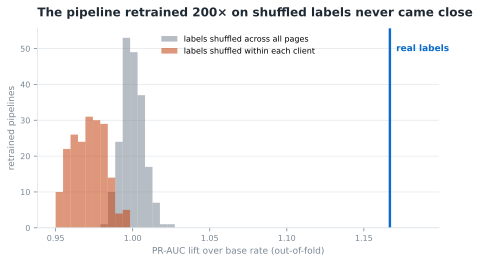

In [2]:
perm = audit["permutation_test"]
print(f"Lift quan sát được (nhãn thật): {perm['observed_lift']:.4f}")
for name in ["global_shuffle", "within_client_shuffle"]:
    s = perm[name]
    print(f"  {name:<22} null mean {s['null_mean']:.4f} · p95 {s['null_p95']:.4f} · "
          f"max {s['null_max']:.4f} · p = {s['p_value']:.3f}")
print(f"\np = {perm['within_client_shuffle']['p_value']:.3f} là giá trị NHỎ NHẤT có thể với "
      f"{perm['n_permutations']} hoán vị: không lần nào chance chạm tới kết quả thật.")
display(SVG(filename=str(FIG / "evidence_permutation.svg")))

## 2. Bootstrap theo client — con số dao động bao nhiêu?

Các trang trong cùng một client tương quan với nhau (cùng site, cùng đội biên tập). Bootstrap theo *dòng*
sẽ giả vờ ta có 18,010 quan sát độc lập — thực tế chỉ có 30 cụm. Vì vậy ta lấy mẫu lại **client** có hoàn lại,
1,000 lần, và chấm *mọi* model trên cùng một mẫu → khoảng cách giữa các model là **ghép cặp**.

Khoảng tin cậy 95% (client bootstrap):


metric                          p@20               p@200                 p@50              pr_auc               roc_auc              
                              95% hi 95% lo point 95% hi 95% lo  point 95% hi 95% lo point 95% hi 95% lo  point  95% hi 95% lo  point
model                                                                                                                                
Logistic regression (shipped)    1.0   0.70  0.90  0.875  0.725  0.815   0.96   0.70  0.88  0.798  0.660  0.718   0.660  0.590  0.641
Rule baseline                    1.0   0.50  0.90  0.860  0.625  0.730   0.96   0.54  0.74  0.796  0.578  0.668   0.595  0.521  0.562
Gradient boosting                0.9   0.50  0.90  0.880  0.645  0.755   0.92   0.54  0.88  0.787  0.653  0.697   0.648  0.540  0.621
Random forest                    1.0   0.40  0.75  0.855  0.625  0.790   0.88   0.42  0.80  0.798  0.656  0.711   0.666  0.571  0.637
Random ordering                  0.9   0.45  0.70  0.760  0.535  0.635   0.74   0.46  0.58  0.741  0.547  0.617   0.505  0.492  0.498


Khoảng cách ghép cặp (dương = model được ship tốt hơn):


,comparison,metric,gap,95% lo,95% hi,share of resamples not better,interval excludes 0
0,model − rule,p@20,0.0000,-0.1000,0.3000,0.521,False
1,model − rule,p@50,0.1400,-0.0600,0.2400,0.126,False
2,model − rule,p@200,0.0850,-0.0500,0.1700,0.090,False
3,model − rule,pr_auc,0.0507,-0.0037,0.0862,0.036,False
4,model − rule,roc_auc,0.0785,0.0039,0.1178,0.020,True
5,model − random,p@20,0.2000,-0.1000,0.5000,0.120,False
6,model − random,p@50,0.3000,0.0400,0.4600,0.009,True
7,model − random,p@200,0.1800,0.0500,0.2850,0.004,True
8,model − random,pr_auc,0.1014,0.0481,0.1219,0.000,True
9,model − random,roc_auc,0.1426,0.0895,0.1631,0.000,True


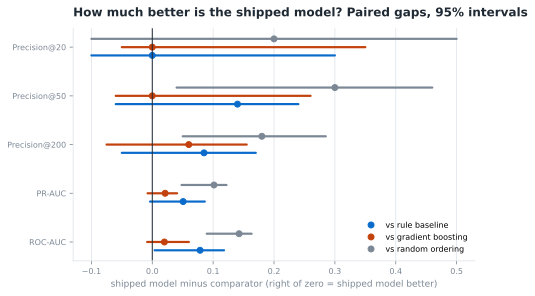

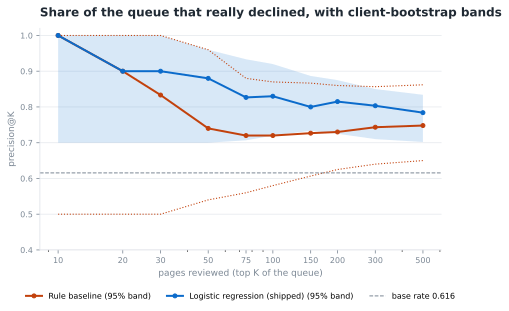

In [3]:
boot = audit["bootstrap"]
rows = []
for model in ["logreg", "rule", "hgb", "rf", "random"]:
    for m, v in boot["intervals"][model].items():
        rows.append({"model": ea.LABELS[model], "metric": m,
                     "point": v["point"], "95% lo": v["lo"], "95% hi": v["hi"]})
iv = pd.DataFrame(rows).pivot_table(index="model", columns="metric",
                                    values=["point", "95% lo", "95% hi"], sort=False)
print("Khoảng tin cậy 95% (client bootstrap):")
display(iv.swaplevel(axis=1).sort_index(axis=1, level=0).round(3))

gaps = []
for key, g in boot["paired_gaps"].items():
    for m, v in g.items():
        gaps.append({"comparison": key.replace("logreg_minus_", "model − "), "metric": m,
                     "gap": v["point"], "95% lo": v["lo"], "95% hi": v["hi"],
                     "share of resamples not better": v["share_resamples_not_better"],
                     "interval excludes 0": v["lo"] > 0})
gaps = pd.DataFrame(gaps)
print("\nKhoảng cách ghép cặp (dương = model được ship tốt hơn):")
display(gaps.round(4))
display(SVG(filename=str(FIG / "evidence_bootstrap.svg")))
display(SVG(filename=str(FIG / "evidence_capacity.svg")))

**Đọc kết quả.** So với rule baseline, khoảng cách trên *toàn bộ thứ hạng* là thật: khoảng tin cậy của ROC-AUC
nằm hẳn bên phải 0, và ~96% mẫu bootstrap nghiêng về model trên PR-AUC. Nhưng **precision@50 đứng một mình
thì không chắc chắn**: khoảng tin cậy của gap cắt qua 0. Với 30 client, "44/50 so với 37/50" là điều *đã xảy ra*
trên snapshot này — không phải lời hứa cho snapshot sau. Cách viết claim phải đổi theo (xem mục Kết luận).

## 3. Bên trong từng client — thắng nhờ xếp trang hay nhờ xếp client?

Một bảng xếp hạng gộp có thể "thắng" chỉ bằng cách đẩy client có tỷ lệ suy giảm cao lên đầu. Để loại trừ
điều đó, tính ROC-AUC **bên trong** từng client (chỉ những client có ≥50 trang và ≥10 trang mỗi lớp).
Client chỉ được hiển thị theo thứ hạng kích thước, không bao giờ theo ID.

Client đủ điều kiện: 18 (phủ 17,811 trang)
Model thắng rule (ROC-AUC trong client): 14/18 · sign test một phía p = 0.0154
Model thắng rule (precision ở top 10% của client): 11/18
Median ROC-AUC: model 0.584 vs rule 0.551
Client mà model < 0.5 (không hơn tung đồng xu): 2


,n,base_rate,top_k,roc_logreg,ptop_logreg,roc_rule,ptop_rule
size_rank,,,,,,,
1,5690,0.5102,569,0.6333,0.7153,0.5335,0.6151
2,3352,0.6331,335,0.6401,0.7910,0.5819,0.7642
3,2168,0.4912,216,0.6125,0.6759,0.5263,0.5370
4,1686,0.8470,168,0.6625,0.9167,0.5614,0.8929
5,970,0.9649,97,0.6081,1.0000,0.5936,0.9691
6,705,0.6922,70,0.6668,0.8571,0.6028,0.8857
7,634,0.6956,63,0.5734,0.8730,0.5343,0.8413
8,568,0.6602,56,0.6720,0.7857,0.5490,0.7143
9,423,0.7660,42,0.5614,0.8333,0.4892,0.8095


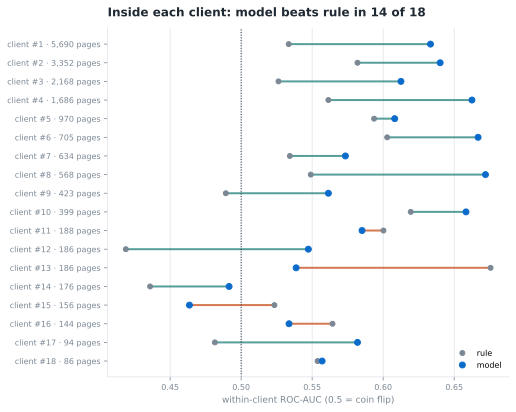

In [4]:
pc = audit["per_client"]
print(f"Client đủ điều kiện: {pc['clients_eligible']} (phủ {pc['pages_covered']:,} trang)")
print(f"Model thắng rule (ROC-AUC trong client): {pc['roc_auc_model_wins']}/{pc['clients_eligible']}"
      f" · sign test một phía p = {pc['roc_auc_sign_test_p']:.4f}")
print(f"Model thắng rule (precision ở top 10% của client): {pc['top10pct_model_wins']}/{pc['clients_eligible']}")
print(f"Median ROC-AUC: model {pc['median_roc_auc_model']:.3f} vs rule {pc['median_roc_auc_rule']:.3f}")
print(f"Client mà model < 0.5 (không hơn tung đồng xu): {pc['clients_where_model_roc_below_0_5']}")
display(pd.DataFrame(pc["clients"]).set_index("size_rank"))
display(SVG(filename=str(FIG / "evidence_per_client.svg")))

## 4. Độ nhạy — đổi định nghĩa thì sao?

Hai lựa chọn chính sách trong pipeline là **ngưỡng demand** (≥100 impressions ở cửa sổ trước) và **ngưỡng suy
giảm** (−20%, theo định nghĩa của sản phẩm). Cả hai đều là quyết định, không phải chân lý. Chạy lại model và
rule trên lưới 4 × 3, và thử bỏ client lớn nhất (31.6% số trang).

In [5]:
sens = audit["sensitivity"]
g = pd.DataFrame(sens["grid"])
g["model − rule (PR-AUC lift)"] = (g["model_pr_auc_lift"] - g["rule_pr_auc_lift"]).round(3)
display(g.set_index(["min_prev30_impressions", "decline_threshold_pct"]))
w, t, l = sens["precision_at_50_model_wins_ties_losses"]
print(f"PR-AUC: model thắng rule ở {sens['model_beats_rule_on_pr_auc_in']}")
print(f"Precision@50: thắng {w}, hoà {t}, thua {l}")

big = audit["largest_client"]
print(f"\nClient lớn nhất chiếm {big['largest_client_share_of_pages']:.1%} số trang.")
for part in ["without_largest_client", "largest_client_only"]:
    b = big[part]
    print(f"  {part:<24} n={b['rows']:>6,}  base {b['base_rate']:.3f}  "
          f"PR-AUC model {b['logreg']['pr_auc']:.3f} vs rule {b['rule']['pr_auc']:.3f}  ·  "
          f"P@50 {b['logreg']['p@50']:.2f} vs {b['rule']['p@50']:.2f}")

rows  base_rate  model_pr_auc_lift  rule_pr_auc_lift  model_p@50  rule_p@50  \
min_prev30_impressions decline_threshold_pct                                                                                 
50                     -10.0                  20249     0.7030              1.087             1.067        0.84       0.92   
                       -20.0                  20249     0.6149              1.144             1.080        0.84       0.78   
                       -30.0                  20249     0.5206              1.216             1.102        0.78       0.72   
100                    -10.0                  18010     0.7083              1.096             1.067        0.90       0.90   
                       -20.0                  18010     0.6155              1.167             1.085        0.88       0.74   
                       -30.0                  18010     0.5174              1.247             1.110        0.78       0.68   
250                    -10.0                  14239     0.7149              1.090             1.063        0.86       0.86   
                       -20.0                  14239     0.6161              1.169             1.081        0.90       0.68   
                       -30.0                  14239     0.5110              1.267             1.116        0.80       0.60   
500                    -10.0                  11119     0.7117              1.103             1.070        0.90       0.86   
                       -20.0                  11119     0.6078              1.178             1.090        0.90       0.68   
                       -30.0                  11119     0.4996              1.276             1.128        0.84       0.60   

                                              model − rule (PR-AUC lift)  
min_prev30_impressions decline_threshold_pct                              
50                     -10.0                                       0.020  
                       -20.0                                       0.064  
                       -30.0                                       0.114  
100                    -10.0                                       0.029  
                       -20.0                                       0.082  
                       -30.0                                       0.137  
250                    -10.0                                       0.027  
                       -20.0                                       0.088  
                       -30.0                                       0.151  
500                    -10.0                                       0.033  
                       -20.0                                       0.088  
                       -30.0                                       0.148

PR-AUC: model thắng rule ở 12 of 12 settings
Precision@50: thắng 9, hoà 2, thua 1

Client lớn nhất chiếm 31.6% số trang.
  without_largest_client   n=12,320  base 0.664  PR-AUC model 0.740 vs rule 0.714  ·  P@50 0.88 vs 0.80
  largest_client_only      n= 5,690  base 0.510  PR-AUC model 0.635 vs rule 0.549  ·  P@50 0.78 vs 0.58


## 5. Độ phức tạp có đáng không?

Một `HistGradientBoostingClassifier` được regularise hợp lý (không phải đối thủ bù nhìn), chấm out-of-fold trên
**đúng các fold** của pipeline.

In [6]:
cc = audit["complexity_check"]
display(pd.DataFrame({"gradient boosting": cc["gradient_boosting"],
                      "logistic regression": cc["logistic_regression"]}).T)
hg = boot["paired_gaps"]["logreg_minus_hgb"]["pr_auc"]
rf = boot["paired_gaps"]["logreg_minus_rf"]["pr_auc"]
print(f"PR-AUC gap model − boosting: {hg['point']:+.4f} [{hg['lo']:+.4f}, {hg['hi']:+.4f}]")
print(f"PR-AUC gap model − forest  : {rf['point']:+.4f} [{rf['lo']:+.4f}, {rf['hi']:+.4f}]")
print(f"Kết luận: {cc['verdict']}. Model dễ đọc được giữ lại vì nó thắng thật, không phải vì nó dễ.")

,p@20,p@50,p@200,pr_auc,roc_auc
gradient boosting,0.9,0.88,0.755,0.6973,0.6207
logistic regression,0.9,0.88,0.815,0.7183,0.6406


PR-AUC gap model − boosting: +0.0211 [-0.0077, +0.0407]
PR-AUC gap model − forest  : +0.0075 [-0.0191, +0.0226]
Kết luận: no — the paired gap favours logistic regression. Model dễ đọc được giữ lại vì nó thắng thật, không phải vì nó dễ.


## 6. Calibration — điểm rủi ro có phải là xác suất không?

  brier                        0.2244
  brier_base_rate_only         0.2366
  brier_skill_score            0.0517
  expected_calibration_error   0.0277
  calibration_slope            0.777
  calibration_intercept        0.051


,n,mean_predicted,observed_rate
bin,,,
1,1801,0.3629,0.4270
2,1801,0.4743,0.4475
3,1801,0.5316,0.5047
4,1801,0.5797,0.5608
5,1801,0.6245,0.6202
6,1801,0.6641,0.6613
7,1801,0.7010,0.7102
8,1801,0.7365,0.7213
9,1801,0.7761,0.7435


Nhãn confidence mà queue in ra có đúng nghĩa không?


,pages,observed_decline_rate,mean_predicted
high,1610.0,0.7770,0.8112
medium,9319.0,0.6867,0.7060
low,7081.0,0.4852,0.4851


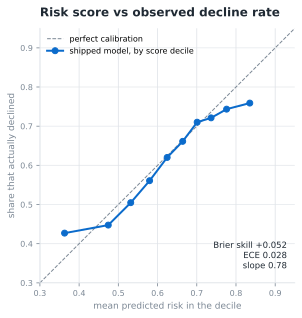

In [7]:
cal = audit["calibration"]
for k in ["brier", "brier_base_rate_only", "brier_skill_score", "expected_calibration_error",
          "calibration_slope", "calibration_intercept"]:
    print(f"  {k:<28} {cal[k]}")
display(pd.DataFrame(cal["reliability"]).set_index("bin"))
print("Nhãn confidence mà queue in ra có đúng nghĩa không?")
display(pd.DataFrame(cal["confidence_labels"]).T)
display(SVG(filename=str(FIG / "evidence_calibration.svg")))

**Đọc kết quả.** Ở giữa dải điểm, model calibrate tốt (các decile nằm trên đường chéo). Ở đỉnh, nó **tự tin
quá mức**: decile rủi ro nhất dự đoán trung bình ~0.84 nhưng chỉ ~0.76 thực sự suy giảm (slope 0.78 < 1). Vì vậy
queue in **nhãn confidence** chứ không in phần trăm — và các nhãn đó có thứ tự đúng (high > medium > low).

## Kết luận — cái gì sống sót, cái gì không, và claim phải đổi thế nào

**Sống sót.**
- Có tín hiệu thật: permutation test p = 0.005 dưới *cả hai* giả thuyết không (giá trị nhỏ nhất 200 hoán vị cho phép).
- Model xếp hạng tốt hơn rule trên toàn thứ hạng (ROC-AUC gap có khoảng tin cậy loại trừ 0), **bên trong** 14/18 client,
  khi bỏ client lớn nhất, bên trong riêng client lớn nhất, và ở 12/12 cấu hình định nghĩa.
- Logistic regression được giữ lại nhờ thắng thật: boosting và random forest đều nằm trong nhiễu, và thấp hơn.

**Không sống sót.**
- "Precision@50 tốt hơn rule" như một claim *đứng một mình*: khoảng tin cậy của gap là [−0.06, +0.24].

**Claim viết lại.**

| Trước | Sau |
|---|---|
| "Model đưa 44/50 trang suy giảm thật vào top 50, rule chỉ 37." | "Trên snapshot này, 44/50 trang đầu của model thực sự suy giảm so với 37/50 của rule; với 30 client, riêng khoảng cách ở top 50 còn nằm trong nhiễu, nhưng lợi thế trên toàn thứ hạng thì không." |
| "Điểm rủi ro 0.83 nghĩa là 83% khả năng suy giảm." | "Đọc điểm như thứ hạng. Nhãn *high* tương ứng khoảng 78% trang thực sự suy giảm." |

## Self-check

- [x] Mọi chỉ số tính out-of-fold, cùng GroupKFold(5) theo client như pipeline chính
- [x] Bootstrap lấy mẫu lại **client**, không phải dòng; khoảng cách giữa các model là ghép cặp
- [x] Permutation test huấn luyện lại *toàn bộ* pipeline, không chỉ xáo điểm số
- [x] Có một giả thuyết không khó hơn (xáo trong client) để loại trừ việc "học client"
- [x] Kết quả tiêu cực (P@50 gap không chắc chắn; calibration ở đỉnh) được báo cáo, không bị giấu
- [x] Không có ID client nào được công bố — chỉ thứ hạng kích thước
- [x] Receipt: `work/outputs/evidence_audit.json`; kiểm tra: `pytest -q tests/`